In [1]:
import sys, os

PROJECT_ROOT = os.path.abspath('..')
LLAVA_DIR    = os.path.join(PROJECT_ROOT, 'LLaVA')
for p in [PROJECT_ROOT, LLAVA_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

from llava_with_tree import load_model

MODEL_ID = '/root/autodl-tmp/Q-Vtree/checkpoints/llava-1.5-7b-hf'

model, processor = load_model(MODEL_ID)
print('Model ready')


/root/miniconda3/envs/mllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 686/686 [00:03<00:00, 222.16it/s]


Model ready


Index        : 159
Question ID  : 159
Category     : relative_position
Image size   : (1500, 2250)
Question     : Is the motorcycle on the left or right side of the street?
Ground truth : A


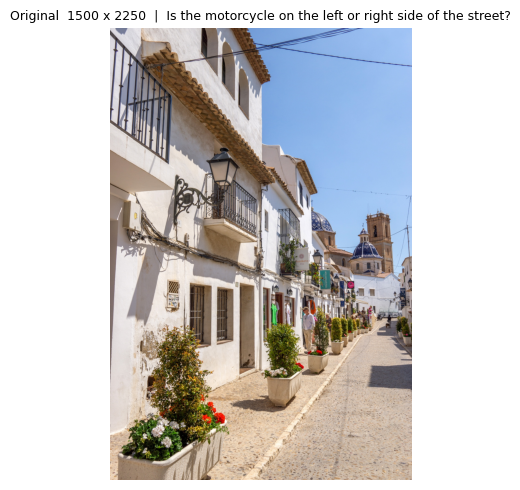

In [2]:
import json, re
import matplotlib.pyplot as plt
from PIL import Image

DATASET_DIR = os.path.join(PROJECT_ROOT, 'datasets', 'vstar_bench')
ANNO_FILE   = os.path.join(DATASET_DIR, 'test_questions.jsonl')

with open(ANNO_FILE) as f:
    samples = [json.loads(l) for l in f]

SAMPLE_IDX = 159  # change this to pick a different sample

sample   = samples[SAMPLE_IDX]
image    = Image.open(os.path.join(DATASET_DIR, sample['image'])).convert('RGB')
question = sample['text']
label    = sample['label']
clean_q  = re.split(r'\n\(A\)', question)[0].strip()

print('Index        :', SAMPLE_IDX)
print('Question ID  :', sample['question_id'])
print('Category     :', sample['category'])
print('Image size   :', image.size)
print('Question     :', clean_q)
print('Ground truth :', label)

plt.figure(figsize=(7, 5))
plt.imshow(image)
plt.axis('off')
plt.title('Original  {} x {}  |  {}'.format(image.size[0], image.size[1], clean_q), fontsize=9)
plt.tight_layout()
plt.show()


Original size : (1500, 2250)
Pad-resized   : (336, 336)
Scale         : 0.1493
Padding (x,y) : (56, 0)


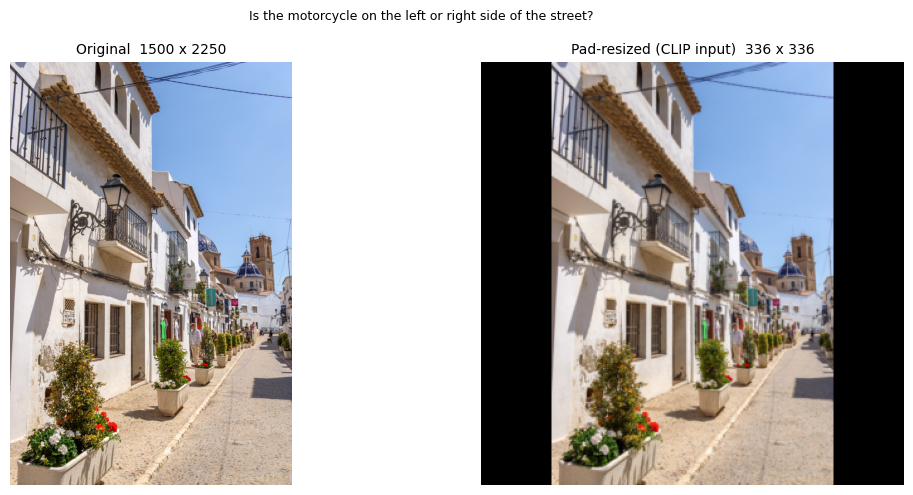

In [3]:
# original image vs pad-resized image sent to CLIP
from llava_with_tree import pad_resize, pad_resize_with_meta

padded, meta = pad_resize_with_meta(image)

print('Original size :', image.size)
print('Pad-resized   :', padded.size)
print('Scale         : {:.4f}'.format(meta.scale))
print('Padding (x,y) : ({}, {})'.format(meta.pad_x, meta.pad_y))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image)
axes[0].axis('off')
axes[0].set_title('Original  {} x {}'.format(image.size[0], image.size[1]), fontsize=10)
axes[1].imshow(padded)
axes[1].axis('off')
axes[1].set_title('Pad-resized (CLIP input)  336 x 336', fontsize=10)
plt.suptitle(clean_q, fontsize=9)
plt.tight_layout()
plt.show()


In [4]:
from llava_with_tree import run_baseline_inference

baseline_answer = run_baseline_inference(model, processor, image, question)

print('Question     :', clean_q)
print('Baseline ans :', baseline_answer)
print('Ground truth :', label)


Question     : Is the motorcycle on the left or right side of the street?
Baseline ans : B
Ground truth : A


patch_scores : shape=torch.Size([576])  min=0.0000  max=1.0000


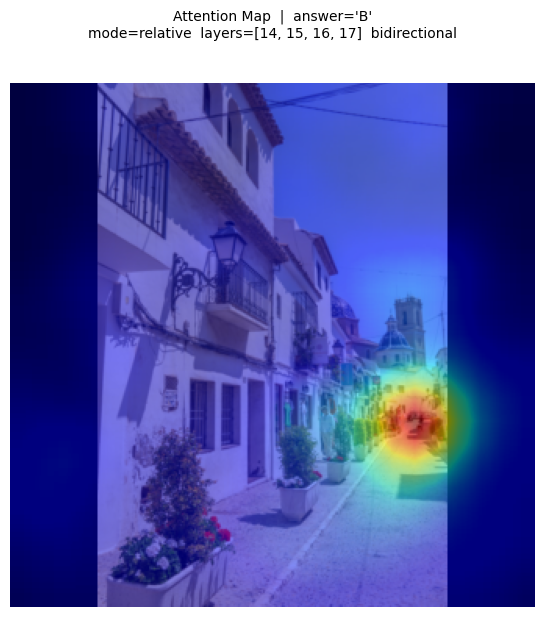

In [5]:
from llava_with_tree import compute_patch_scores, recover_clip_image
from attention_viz   import visualize_attention

TARGET_LAYERS = (14, 15, 16, 17)

# clip_image is the pad-resized 336x336 image
clip_image   = recover_clip_image(processor, image, question)
patch_scores = compute_patch_scores(
    model, processor, image, clean_q,
    target_layers=TARGET_LAYERS,
)

print('patch_scores : shape={}  min={:.4f}  max={:.4f}'.format(
    patch_scores.shape, patch_scores.min(), patch_scores.max()
))

visualize_attention(
    image=clip_image,
    attn_result={
        'patch_scores' : patch_scores,
        'answer'       : baseline_answer,
        'use_relative' : True,
        'grid_size'    : 24,
        'target_layers': TARGET_LAYERS,
    },
    alpha=0.5,
)


Selected : 10 / 576  (1.7%)


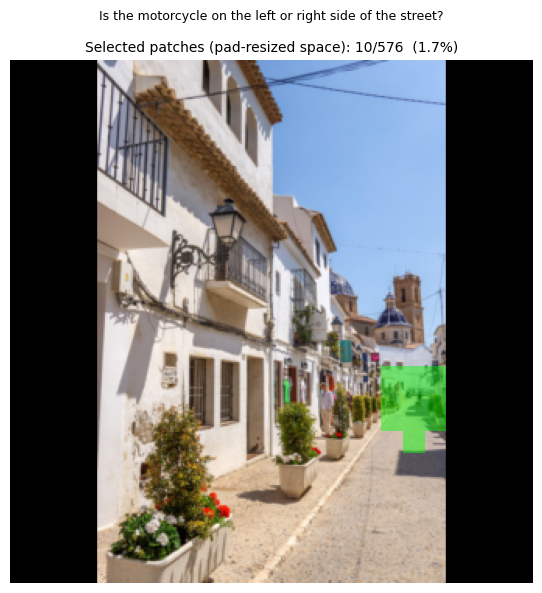

In [6]:
import numpy as np
import matplotlib.patches as mpatches
from llava_with_tree import select_patches, GRID_SIZE, PATCH_SIZE

SPLIT_THRESHOLD = 0.3
SOFTMAX_TEMP    = 0.2

patch_ids    = select_patches(patch_scores, SPLIT_THRESHOLD, SOFTMAX_TEMP)
num_selected = patch_ids.numel()
num_total    = GRID_SIZE * GRID_SIZE

print('Selected : {} / {}  ({:.1f}%)'.format(num_selected, num_total, num_selected/num_total*100))

# show selected patches on pad-resized image (336x336 space)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(clip_image)
for pid in patch_ids.tolist():
    r, c = int(pid) // GRID_SIZE, int(pid) % GRID_SIZE
    rect = mpatches.Rectangle(
        (c * PATCH_SIZE, r * PATCH_SIZE), PATCH_SIZE, PATCH_SIZE,
        linewidth=0, facecolor='lime', alpha=0.45,
    )
    ax.add_patch(rect)
ax.axis('off')
ax.set_title(
    'Selected patches (pad-resized space): {}/{}  ({:.1f}%)'.format(
        num_selected, num_total, num_selected/num_total*100),
    fontsize=10,
)
plt.suptitle(clean_q, fontsize=9)
plt.tight_layout()
plt.show()


Original image  : (1500, 2250)
Compact image   : (281, 375)
Merged boxes    : 10


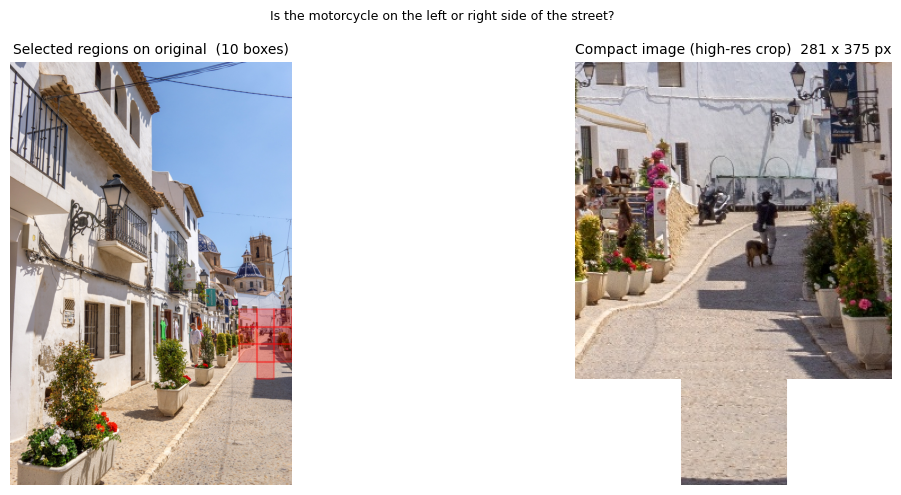

In [7]:
import matplotlib.patches as mpatches
from llava_with_tree import run_lpd, run_lpd_on_original

# LPD on 336x336 for visualization
_, merged_bboxes_336 = run_lpd(patch_ids, clip_image)

# LPD on original high-res image for inference
compact_image, merged_bboxes = run_lpd_on_original(patch_ids, image, meta)

print('Original image  :', image.size)
print('Compact image   :', compact_image.size)
print('Merged boxes    :', len(merged_bboxes))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: selected regions on original image
axes[0].imshow(image)
for (x0, y0, x1, y1) in merged_bboxes:
    rect = mpatches.Rectangle(
        (x0, y0), x1-x0, y1-y0,
        linewidth=1.5, edgecolor='red', facecolor='red', alpha=0.25,
    )
    axes[0].add_patch(rect)
axes[0].axis('off')
axes[0].set_title(
    'Selected regions on original  ({} boxes)'.format(len(merged_bboxes)), fontsize=10
)

# right: compact image cropped from original
axes[1].imshow(compact_image)
axes[1].axis('off')
axes[1].set_title(
    'Compact image (high-res crop)  {} x {} px'.format(
        compact_image.size[0], compact_image.size[1]),
    fontsize=10,
)

plt.suptitle(clean_q, fontsize=9)
plt.tight_layout()
plt.show()


In [8]:
from llava_with_tree import run_tree_inference

tree_answer = run_tree_inference(model, processor, compact_image, question)

print('=' * 52)
print('  Question     :', clean_q)
print('  Ground truth :', label)
print('-' * 52)
print('  Baseline     :', baseline_answer)
print('-' * 52)
print('  Tree         :', tree_answer)
print('  Tokens used  : {}/{}  ({:.1f}%)'.format(
    num_selected, num_total, num_selected/num_total*100))
print('=' * 52)


  Question     : Is the motorcycle on the left or right side of the street?
  Ground truth : A
----------------------------------------------------
  Baseline     : B
----------------------------------------------------
  Tree         : A
  Tokens used  : 10/576  (1.7%)
